In [146]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.cluster import KMeans 
import seaborn as sns

In [147]:
#Loading the dataset
df=pd.DataFrame(pd.read_csv('Mall_Customers - Mall_Customers.csv'))

In [148]:
# Shape of Dataset
df.shape

(200, 5)

In [149]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [150]:
#Datatypes in dataset
df.dtypes

CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [151]:
#Describing the data
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [152]:
#number of zeros
(df==0).sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [153]:
#Check for Null Values
(df.isnull()).sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [154]:
df=df.drop(columns=['CustomerID'])

In [155]:
df

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [156]:
df.mean(numeric_only=True)

Age                       38.85
Annual Income (k$)        60.56
Spending Score (1-100)    50.20
dtype: float64

In [157]:
df.median(numeric_only=True)

Age                       36.0
Annual Income (k$)        61.5
Spending Score (1-100)    50.0
dtype: float64

In [192]:
df.mode()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Female,32.0,54,42.0
1,NaN,NaN,78,NaN


In [193]:
df.std()

/tmp/ipykernel_5062/3390915376.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df.std()


Age                       13.969007
Annual Income (k$)        26.264721
Spending Score (1-100)    25.823522
dtype: float64

In [194]:
 #sns.pairplot(df)

<AxesSubplot:xlabel='Age', ylabel='Count'>

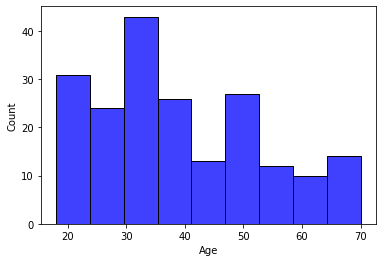

In [195]:
sns.histplot(data=df,x='Age',color='blue')

<AxesSubplot:xlabel='Spending Score (1-100)', ylabel='Count'>

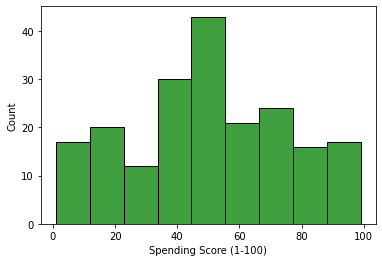

In [196]:
sns.histplot(data=df,x='Spending Score (1-100)',color='green')

<AxesSubplot:xlabel='Annual Income (k$)', ylabel='Count'>

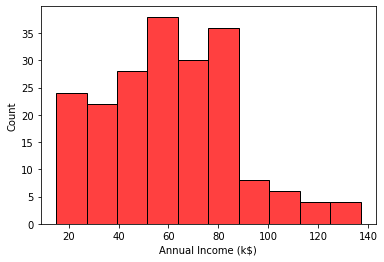

In [197]:
sns.histplot(data=df,x='Annual Income (k$)',color='red')

<AxesSubplot:xlabel='Spending Score (1-100)', ylabel='count'>

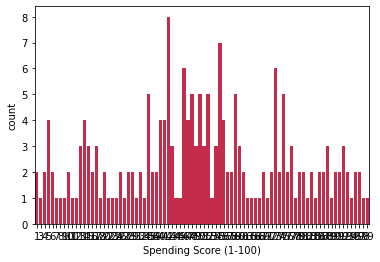

In [198]:
sns.countplot(data=df,x=df['Spending Score (1-100)'],color='crimson')

<AxesSubplot:>

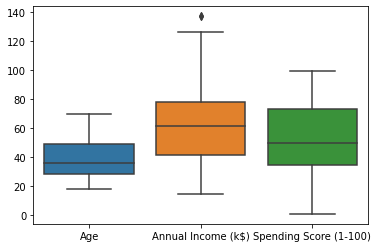

In [199]:
sns.boxplot(data=df)

In [200]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

<AxesSubplot:xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

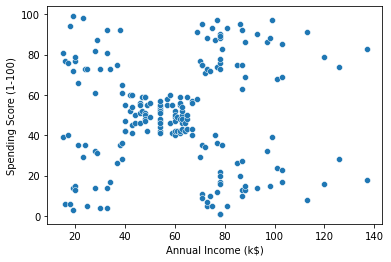

In [231]:
sns.scatterplot(data=X,x='Annual Income (k$)',y='Spending Score (1-100)')

In [250]:
kmeans=KMeans(n_clusters=3)

In [242]:
kmeans.fit(X)

KMeans(n_clusters=3)

In [243]:
cluster=kmeans.predict(X)

In [244]:
kmeans.cluster_centers_


array([[87.        , 18.63157895],
       [86.53846154, 82.12820513],
       [44.15447154, 49.82926829]])

In [245]:
kmeans.inertia_

106348.37306211119

In [246]:
kmeans.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1], dtype=int32)

<AxesSubplot:xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

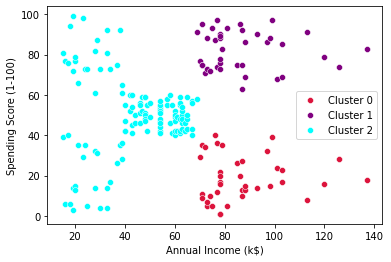

In [247]:
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==0],y=X['Spending Score (1-100)'][kmeans.labels_==0],label='Cluster 0',color='crimson')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==1],y=X['Spending Score (1-100)'][kmeans.labels_==1],label='Cluster 1',color='purple')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==2],y=X['Spending Score (1-100)'][kmeans.labels_==2],label='Cluster 2',color='cyan')

In [248]:
wcss= []
for k in range (1,16):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
wcss    

[269981.28,
 183811.28277016425,
 106348.3730621112,
 73880.64496247195,
 44454.47647967974,
 37265.86520484346,
 30566.45113025186,
 28382.177654552743,
 23265.913908959254,
 21089.820499108733,
 18222.210767184704,
 17397.899646464648,
 14988.935093206394,
 13962.511070289358,
 12900.560483084168]

<AxesSubplot:>

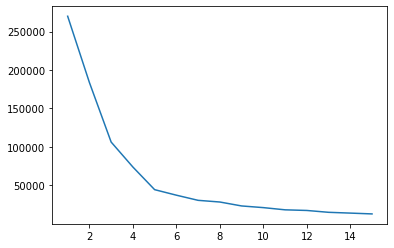

In [249]:
sns.lineplot(x=list(range(1,16)),y=wcss)

In [251]:
kmeans=KMeans(n_clusters=5)

In [252]:
kmeans.fit(X)

KMeans(n_clusters=5)

In [253]:
cluster=kmeans.predict(X)

In [256]:
kmeans.cluster_centers_


array([[ 48.16831683,  43.3960396 ],
       [ 84.52777778,  18.38888889],
       [120.375     ,  63.75      ],
       [ 25.72727273,  79.36363636],
       [ 81.06060606,  83.        ]])

In [257]:
kmeans.inertia_

67818.53314081408

In [258]:
kmeans.labels_

array([0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 0,
       0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 2, 1, 4, 1, 2, 1, 2, 1, 2, 2, 2,
       2, 2], dtype=int32)

<AxesSubplot:xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

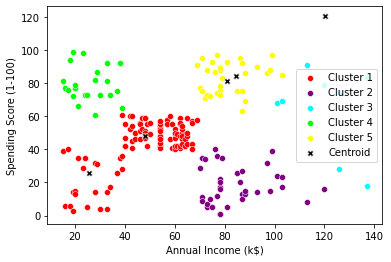

In [267]:
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==0],y=X['Spending Score (1-100)'][kmeans.labels_==0],label='Cluster 1',color='red')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==1],y=X['Spending Score (1-100)'][kmeans.labels_==1],label='Cluster 2',color='purple')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==2],y=X['Spending Score (1-100)'][kmeans.labels_==2],label='Cluster 3',color='cyan')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==3],y=X['Spending Score (1-100)'][kmeans.labels_==3],label='Cluster 4',color='lime')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==4],y=X['Spending Score (1-100)'][kmeans.labels_==4],label='Cluster 5',color='yellow')
sns.scatterplot(data=kmeans.cluster_centers_,x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,0],label='Centroid',marker='X',color='black')


Enter annual Income120
Enter spending score100


/home/student/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Entered point is in  3


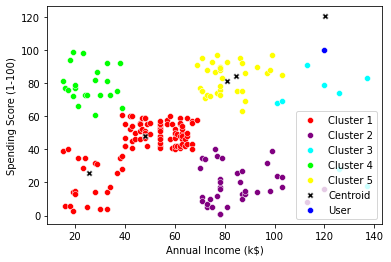

In [269]:
A_I=int(input('Enter annual Income'))
S_S=int(input('Enter spending score'))
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==0],y=X['Spending Score (1-100)'][kmeans.labels_==0],label='Cluster 1',color='red')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==1],y=X['Spending Score (1-100)'][kmeans.labels_==1],label='Cluster 2',color='purple')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==2],y=X['Spending Score (1-100)'][kmeans.labels_==2],label='Cluster 3',color='cyan')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==3],y=X['Spending Score (1-100)'][kmeans.labels_==3],label='Cluster 4',color='lime')
sns.scatterplot(data=X,x=X['Annual Income (k$)'][kmeans.labels_==4],y=X['Spending Score (1-100)'][kmeans.labels_==4],label='Cluster 5',color='yellow')
sns.scatterplot(data=kmeans.cluster_centers_,x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,0],label='Centroid',marker='X',color='black')
sns.scatterplot(x=[A_I],y=[S_S],color='blue',label='User')
print("Entered point is in ",(kmeans.predict([[A_I,S_S]]))[0]+1)